# SYNERISE → MixRec Preprocessing Pipeline (v2 — 2 behaviors)
**Behaviors used:** `add_to_cart` (Cart) + `product_buy` (Buy)  
**Dropped:** `page_visit` (url ≠ sku space)

### Output file structure:
```
Datasets/synerise/
├── trn_Cart.pkl      # scipy CSR sparse matrix (users × items, add_to_cart train)
├── trn_Buy.pkl       # scipy CSR sparse matrix (users × items, product_buy train)
├── tst_Buy.pkl       # dict {user_id: [item_ids]}  (leave-one-out test)
├── stats.json        # {n_users, n_items}
├── user2id.pkl       # {raw_id → int}
└── item2id.pkl       # {raw_id → int}
```

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import scipy
import scipy.sparse as sp
import pickle, json, os

print('pandas :', pd.__version__)
print('numpy  :', np.__version__)
print('scipy  :', scipy.__version__)

DATA_DIR = '/kaggle/input/datasets/sarahalhalees/synerise-dataset'
OUT_DIR  = '/kaggle/working/Datasets/synerise'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Output dir ready: {OUT_DIR}')

pandas : 2.3.3
numpy  : 2.0.2
scipy  : 1.16.3
Output dir ready: /kaggle/working/Datasets/synerise


In [2]:
# Cell 2 — Config
MIN_INTERACTIONS = 2   # k-core threshold (per user and per item, across both behaviors)
MIN_BUY_PER_USER = 2   # need ≥1 for train + ≥1 for test (leave-one-out)
SEED = 42

In [3]:
# Cell 3 — Load raw parquet files (only 2 behaviors, only needed columns)
cart_raw = pd.read_parquet(os.path.join(DATA_DIR, 'add_to_cart.parquet'),
                           columns=['client_id', 'sku'])
buy_raw  = pd.read_parquet(os.path.join(DATA_DIR, 'product_buy.parquet'),
                           columns=['client_id', 'sku'])

print(f'cart_raw : {len(cart_raw):,} rows')
print(f'buy_raw  : {len(buy_raw):,} rows')
print('\ncart_raw sample:')
print(cart_raw.head(3))
print('\nbuy_raw sample:')
print(buy_raw.head(3))

cart_raw : 7,541,117 rows
buy_raw  : 2,318,502 rows

cart_raw sample:
   client_id      sku
0   18080713   219064
1    8081030  1375125
2    4480154  1291128

buy_raw sample:
   client_id      sku
0   14534769    91300
1   14534769   660194
2    4480154  1291128


In [4]:
# Cell 4 — Standardise: rename columns, drop nulls, deduplicate
def standardise(df):
    df = df.rename(columns={'client_id': 'user', 'sku': 'item'}).copy()
    df = df.dropna()
    df['user'] = df['user'].astype(str)
    df['item'] = df['item'].astype(str)
    df = df.drop_duplicates(subset=['user', 'item'])
    return df.reset_index(drop=True)

cart = standardise(cart_raw)
buy  = standardise(buy_raw)
del cart_raw, buy_raw

print(f'cart : {len(cart):,} unique (user, item) pairs')
print(f'buy  : {len(buy):,}  unique (user, item) pairs')
print(f'\nUnique users in cart : {cart.user.nunique():,}')
print(f'Unique items in cart : {cart.item.nunique():,}')
print(f'Unique users in buy  : {buy.user.nunique():,}')
print(f'Unique items in buy  : {buy.item.nunique():,}')

cart : 5,791,963 unique (user, item) pairs
buy  : 1,817,928  unique (user, item) pairs

Unique users in cart : 2,333,463
Unique items in cart : 1,444,160
Unique users in buy  : 909,210
Unique items in buy  : 639,126


In [5]:
# Cell 5 — K-core filtering (iterative, converges when no more nodes removed)
# Removes users/items with fewer than MIN_INTERACTIONS across both behaviors combined.

def kcore_filter(dfs, min_count=MIN_INTERACTIONS, max_iter=20):
    all_df = pd.concat(dfs, ignore_index=True)
    for i in range(max_iter):
        n_before = len(all_df)
        valid_u = set(all_df['user'].value_counts().pipe(lambda s: s[s >= min_count]).index)
        valid_i = set(all_df['item'].value_counts().pipe(lambda s: s[s >= min_count]).index)
        all_df = all_df[all_df['user'].isin(valid_u) & all_df['item'].isin(valid_i)]
        print(f'  iter {i+1}: {n_before:,} → {len(all_df):,} rows  ({n_before - len(all_df):,} removed)')
        if len(all_df) == n_before:
            print(f'  Converged.')
            break
    final_u = set(all_df['user'].unique())
    final_i = set(all_df['item'].unique())
    filtered = [df[df['user'].isin(final_u) & df['item'].isin(final_i)].copy() for df in dfs]
    return filtered, final_u, final_i

print('=== K-Core Filtering (min interactions =', MIN_INTERACTIONS, ')===')
[cart, buy], valid_users, valid_items = kcore_filter([cart, buy])

print(f'\nAfter k-core:')
print(f'  Users : {len(valid_users):,}')
print(f'  Items : {len(valid_items):,}')
print(f'  cart  : {len(cart):,} interactions')
print(f'  buy   : {len(buy):,} interactions')

=== K-Core Filtering (min interactions = 2 )===
  iter 1: 7,609,891 → 5,581,157 rows  (2,028,734 removed)
  iter 2: 5,581,157 → 5,469,416 rows  (111,741 removed)
  iter 3: 5,469,416 → 5,448,226 rows  (21,190 removed)
  iter 4: 5,448,226 → 5,445,124 rows  (3,102 removed)
  iter 5: 5,445,124 → 5,444,498 rows  (626 removed)
  iter 6: 5,444,498 → 5,444,391 rows  (107 removed)
  iter 7: 5,444,391 → 5,444,368 rows  (23 removed)
  iter 8: 5,444,368 → 5,444,362 rows  (6 removed)
  iter 9: 5,444,362 → 5,444,361 rows  (1 removed)
  iter 10: 5,444,361 → 5,444,361 rows  (0 removed)
  Converged.

After k-core:
  Users : 1,059,121
  Items : 691,084
  cart  : 3,911,851 interactions
  buy   : 1,532,510 interactions


In [6]:
# Cell 6 — Build contiguous integer ID maps
# Neural networks need integer indices 0..N-1, not raw string IDs.

user_list = sorted(valid_users)
item_list = sorted(valid_items)

user2id = {u: i for i, u in enumerate(user_list)}
item2id = {it: i for i, it in enumerate(item_list)}

n_users = len(user2id)
n_items = len(item2id)

print(f'n_users = {n_users:,}')
print(f'n_items = {n_items:,}')

def remap(df):
    df = df.copy()
    df['user'] = df['user'].map(user2id)
    df['item'] = df['item'].map(item2id)
    return df.dropna().astype(int)

cart = remap(cart)
buy  = remap(buy)

# Save maps (needed later to interpret model outputs)
with open(os.path.join(OUT_DIR, 'user2id.pkl'), 'wb') as f:
    pickle.dump(user2id, f)
with open(os.path.join(OUT_DIR, 'item2id.pkl'), 'wb') as f:
    pickle.dump(item2id, f)

print(f'\nSample remapped cart row: {cart.iloc[0].to_dict()}')
print(f'Sample remapped buy  row: {buy.iloc[0].to_dict()}')
print('ID maps saved.')

n_users = 1,059,121
n_items = 691,084

Sample remapped cart row: {'user': 787320, 'item': 137963}
Sample remapped buy  row: {'user': 222179, 'item': 649765}
ID maps saved.


In [7]:
# Cell 7 — Train / Test split (leave-one-out on purchases)
#
# For each user: hold out their LAST purchase as the test item.
# "Last" = highest item id (deterministic, since we dropped timestamps).
# Users with only 1 purchase are excluded (nothing left for training).

buy_counts = buy.groupby('user').size()
eligible   = set(buy_counts[buy_counts >= MIN_BUY_PER_USER].index)

print(f'Users with >= {MIN_BUY_PER_USER} purchases : {len(eligible):,} / {n_users:,}')

buy_eligible = buy[buy['user'].isin(eligible)].copy()
buy_sorted   = buy_eligible.sort_values(['user', 'item'])

test_rows  = buy_sorted.groupby('user').tail(1)       # last item per user → test
train_rows = buy_sorted.drop(test_rows.index)         # everything else   → train

# Test dict: {user_int_id: [item_int_id]}
test_dict = test_rows.groupby('user')['item'].apply(list).to_dict()

print(f'Buy train interactions : {len(train_rows):,}')
print(f'Buy test users         : {len(test_dict):,}')

# Also keep non-eligible users' buy interactions in train (they have only 1 purchase)
buy_non_eligible = buy[~buy['user'].isin(eligible)]
train_rows_full  = pd.concat([train_rows, buy_non_eligible], ignore_index=True)
print(f'Buy train (all users)  : {len(train_rows_full):,}')

Users with >= 2 purchases : 295,088 / 1,059,121
Buy train interactions : 890,930
Buy test users         : 295,088
Buy train (all users)  : 1,237,422


In [8]:
# Cell 8 — Build scipy sparse matrices
#
# CSR (Compressed Sparse Row) matrix: memory-efficient, fast row slicing.
# Shape: (n_users, n_items). Entry [u, i] = 1 means user u interacted with item i.

def build_sparse(df, shape):
    rows = df['user'].values
    cols = df['item'].values
    data = np.ones(len(rows), dtype=np.float32)
    return sp.csr_matrix((data, (rows, cols)), shape=shape)

shape = (n_users, n_items)

mat_cart    = build_sparse(cart,           shape)
mat_buy_trn = build_sparse(train_rows_full, shape)

print('Sparse matrices built:')
print(f'  mat_cart    : {mat_cart.shape}   nnz={mat_cart.nnz:,}')
print(f'  mat_buy_trn : {mat_buy_trn.shape}   nnz={mat_buy_trn.nnz:,}')

print(f'\nDensity:')
total = n_users * n_items
print(f'  cart : {mat_cart.nnz / total * 100:.6f}%')
print(f'  buy  : {mat_buy_trn.nnz / total * 100:.6f}%')
print(f'  ratio cart/buy : {mat_cart.nnz / max(mat_buy_trn.nnz, 1):.1f}x')

Sparse matrices built:
  mat_cart    : (1059121, 691084)   nnz=3,911,851
  mat_buy_trn : (1059121, 691084)   nnz=1,237,422

Density:
  cart : 0.000534%
  buy  : 0.000169%
  ratio cart/buy : 3.2x


In [9]:
# Cell 9 — Save all output files

def save_pkl(obj, filename):
    path = os.path.join(OUT_DIR, filename)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {filename:25s}  {size_kb:8,.0f} KB')

print('=== Saving files ===')
save_pkl(mat_cart,    'trn_Cart.pkl')
save_pkl(mat_buy_trn, 'trn_Buy.pkl')
save_pkl(test_dict,   'tst_Buy.pkl')

stats = {'n_users': n_users, 'n_items': n_items}
with open(os.path.join(OUT_DIR, 'stats.json'), 'w') as f:
    json.dump(stats, f, indent=2)
print(f'  {"stats.json":25s}  (inline)')

print(f'\n=== stats.json ===')
print(json.dumps(stats, indent=2))

=== Saving files ===
  trn_Cart.pkl                 34,699 KB
  trn_Buy.pkl                  13,805 KB
  tst_Buy.pkl                   3,709 KB
  stats.json                 (inline)

=== stats.json ===
{
  "n_users": 1059121,
  "n_items": 691084
}


In [10]:
# Cell 10 — Sanity checks

print('=== SANITY CHECKS ===')

# 1. Shape
assert mat_cart.shape    == (n_users, n_items)
assert mat_buy_trn.shape == (n_users, n_items)
print('✓  Matrix shapes consistent')

# 2. No test leakage
leakage = sum(mat_buy_trn[u, i] > 0 for u, items in test_dict.items() for i in items)
assert leakage == 0, f'LEAKAGE: {leakage} test items found in train matrix!'
print('✓  No train/test leakage')

# 3. Binary values
assert mat_cart.max()    == 1.0
assert mat_buy_trn.max() == 1.0
print('✓  All matrices binary (0/1)')

# 4. Test users have at least 1 train purchase
users_with_train = sum(1 for u in test_dict if mat_buy_trn[u].nnz > 0)
print(f'✓  Test users with >= 1 train purchase: {users_with_train:,} / {len(test_dict):,}')

print('\n=== ALL CHECKS PASSED ===')

=== SANITY CHECKS ===
✓  Matrix shapes consistent
✓  No train/test leakage
✓  All matrices binary (0/1)
✓  Test users with >= 1 train purchase: 295,088 / 295,088

=== ALL CHECKS PASSED ===


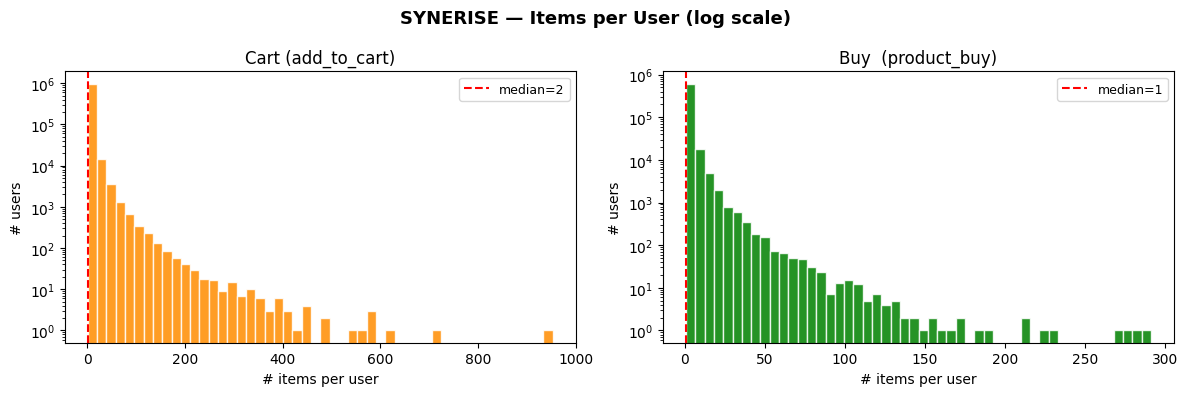

Plot saved.


In [11]:
# Cell 11 — Distribution plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SYNERISE — Items per User (log scale)', fontsize=13, fontweight='bold')

for ax, (title, mat, color) in zip(axes, [
    ('Cart (add_to_cart)',  mat_cart,    'darkorange'),
    ('Buy  (product_buy)',  mat_buy_trn, 'green'),
]):
    deg = np.array(mat.sum(axis=1)).flatten()
    deg = deg[deg > 0]
    ax.hist(deg, bins=50, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('# items per user')
    ax.set_ylabel('# users')
    ax.set_yscale('log')
    ax.axvline(np.median(deg), color='red', linestyle='--',
               label=f'median={np.median(deg):.0f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'distributions.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [12]:
# Cell 12 — Final file listing
print(f'=== OUTPUT FILES in {OUT_DIR} ===')
for fname in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
    print(f'  {fname:30s}  {size:8,.1f} KB')

print('\n=== PREPROCESSING COMPLETE ===')
print('Next: upload these files as a Kaggle dataset, then open Notebook 2 (MixRec model).')

=== OUTPUT FILES in /kaggle/working/Datasets/synerise ===
  distributions.png                   42.0 KB
  item2id.pkl                      9,535.3 KB
  stats.json                           0.0 KB
  trn_Buy.pkl                     13,805.0 KB
  trn_Cart.pkl                    34,699.0 KB
  tst_Buy.pkl                      3,708.5 KB
  user2id.pkl                     15,945.0 KB

=== PREPROCESSING COMPLETE ===
Next: upload these files as a Kaggle dataset, then open Notebook 2 (MixRec model).
